<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi

</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 6</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 7</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- **Aufgabe 07_01_A**
- Aufgabe 07_01_B
- Aufgabe 07_02

## Aufgabe 1 Teil A) Numerov-Integration und Shooting Algorithmus

---

In der Vorlesung wurde die Numerov-Integration in Kombination mit der Shooting Methode eingeführt, um Differentialgleichungen der Form

$$
    \partial_x^2\psi(x) = \kappa(x) \psi(x) \\
    \psi(x_{min}) = \psi_A \\
    \psi(x_{max}) = \psi_B
$$

zu lösen.

Die `Numerov-Integration` dieses Problems ist dabei durch die Vorschrift
$$
    \psi(x_n + \epsilon) = \left\lbrace 2 \left(1 - \frac{5 \epsilon^2}{12} \kappa(x_n) \right) \psi(x_n)
                         - \left(1 + \frac{\epsilon^2}{12} \kappa(x_n - \epsilon)\right) \psi(x_n-\epsilon) \right\rbrace
                           \frac{1}{1 + \epsilon^2/12 \kappa(x_n + \epsilon)}
$$
definiert, wobei  $x_n = x_{min} + \epsilon(n-1)$ gilt mit $n$ von $1$ bis $N$. Die $x_n$ definieren dabei die Diskretisierung des Raumes und mit $\psi_n := \psi(x_n)$ bezeichnen wir im Folgenden die Diskretisierung
der Lösung.

Da es sich um eine Differentialgleichung zweiter Ordnung handelt, braucht man auch zwei Anfangsbedingungen, um den Algorithmus zu vervollständigen:

$$
    \psi_1 = \psi(x_{min}) = \psi_A \\
    \psi_2 = \psi(x_{min} + \epsilon) = c_1
$$

Dabei ist $\psi_0$ durch das ursprüngliche Problem vorgegeben und $c_1$ muss eventuell angepasst werden, um die zweite Randbedingung $\psi_N = \psi(x_{max}) = \psi_B$ zu erfüllen. 
Um das zu erreichen, wurde in der Vorlesung der `Shooting Algorithmus` eingefuehrt.

---

> **Aufgabe**:
> - Was ist die Fehlerabschätzung der Numerov-Integration?
> - Beschreiben Sie kurz das Vorgehen bei dem Shooting Algorithmus

---

Lokale h^6 , Global h^4



### Stationäre Schrödingergleichung

Probleme der oben beschriebenen Form treten beim Lösen der stationären Schrödingergleichung (SSG) in einem beliebigen Potential auf. Dabei ist die SSG im Allgemeinen definiert als:

$$
     H \psi = E \psi \\
     H = \frac{p^2}{2m} + V(x) \\
     p = -i\partial_x
$$

wobei wir $\hbar = 1$ gesetzt haben. 
Diese Gleichung beschreibt das Verhalten eines quantenmechanischen Teilchens in einem Potential, beschrieben durch `V(x)`. 

Im Folgenden soll das Problem mithilfe des `Numerov + Shooting Algorithmus` gelöst werden, wobei für die Potentiale $V(x)$ verschiedene Potentialtöpfe benutzt werden sollen.
Dabei ist ein Potentialtopf im Allgemeinen definiert durch:

$$
     V(x) = \begin{cases}
               f(x)    &\text{für} \ x\in [x_{min}, x_{max}] := \mathcal{I}\\
               \infty  &\text{sonst}
            \end{cases}
$$
wobei $f(x)$ eine beliebige Funktion auf dem Intervall $\mathcal{I}$ ist.

Für diese Art von Potential kann gezeigt werden, dass die Wellenfunktion $\psi(x)$ außerhalb von $\mathcal{I}$ verschwinden muss:
$$
     \psi|_{\mathbb{R}\setminus\mathcal{I}}(x) \equiv 0
$$

wodurch man die folgenden Randbedingungen für die stationäre Schrödingergleichung bekommt:

$$
     \psi(x_{min}) = \psi(x_{max}) = 0 \, .
$$

Um die Anzahl der Parameter zu reduzieren, fixieren Sie im Folgenden die folgenden Werte:

- `x_min = -1` 
- `x_max = 1`
- `N = 1000`
- `ϵ = (x_min - x_max)/(N - 1)`
    
Da nun auch die Energie `E` ein freier unbekannter Parameter ist, besteht hier der Shooting-Algorithmus darin, dass man zu einem gegebenen $E$ die SSG integriert und dann überprüft, ob die Randbedingungen bei $x_{max}$ erfüllt werden.

Da die Randbedingungen bei $x_{max}$ $\psi_N = 0$ sind, ist es des Weiteren auch unwichtig, wie man den 2. Startwert $c_1$ wählt. Daher nehmen Sie im Folgenden die Startwerte:

$$
     \psi(-1) = 0 \\
     \psi(-0.998) = 1
$$

### a) Implementierung der Numerov-Integration

---

Schreiben Sie nun eine Funktion `numerov(f,E)`, welche zu einer gegebenen Funktion $f(x)$ und einer Energie $E$ mithilfe des Numerov-Algorithmus die SSG integriert und die Wellenfunktion zurückgibt.

Da man normalerweise in der Quantenmechanik fordert, dass

$$
     \int_\mathbb{R} \! \mathrm{d}x\, |\psi(x)|^2 = 1
$$

gilt, wollen wir, dass unsere Wellenfunktion dieselbe Normierung erfüllt.

In [3]:
function numerov(V,E; xmin = -1, xmax = 1, N = 1000)
    epsilon = (xmax - xmin) / (N - 1)
    x_range = collect(range(xmin, xmax, length=N))
    
    # Berechne kappa(x) = 2 * (V(x) - E) für alle x
    # Da wir hbar = 1 und m = 1 annehmen.
    kappa = [2.0 * (V(x) - E) for x in x_range]
    
    ψ = zeros(Float64, N)
    
    # Startwerte aus der Aufgabenstellung
    ψ[1] = 0.0
    ψ[2] = 1.0  # c_1 = 1
    
    # Numerov-Iterationsschleife
    fac = epsilon^2 / 12.0
    for n in 2:(N-1)
        # Numerov-Formel umgestellt nach psi[n+1]
        term1 = 2.0 * (1.0 - 5.0 * fac * kappa[n]) * ψ[n]
        term2 = (1.0 + fac * kappa[n-1]) * ψ[n-1]
        denom = 1.0 + fac * kappa[n+1]
        
        ψ[n+1] = (term1 - term2) / denom
    end
    
    # Numerische Normierung (Trapezregel oder Riemann-Summe)
    # Integral von |ψ|^2 dx ≈ epsilon * sum(ψ.^2)
    norm_factor = sqrt(epsilon * sum(ψ.^2))
    if norm_factor > 0
        ψ ./= norm_factor
    end
    
    return ψ, x_range
end



numerov (generic function with 1 method)

### b) Visualisierung

---

Tragen Sie die Endpunkte der Numerov-Wellenfunktion gegen verschiedene Energien für `V(x) = 0` auf. 

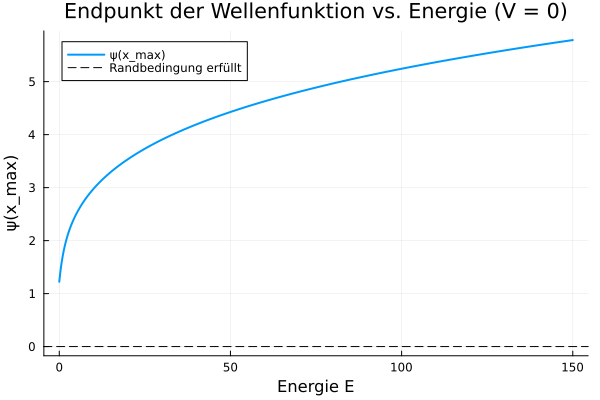

In [4]:
using Plots

# Definiere den Energiebereich für das freie Teilchen (V1 = 0)
E_vals = range(0.0, 150.0, length=500)
psi_end = Float64[]

for E in E_vals
    psi, _ = numerov(x -> 0.0, E)
    push!(psi_end, psi[end]) # Letzter Punkt ψ_N
end

# Plotten der Funktion ψ_N(E)
plot(E_vals, psi_end, label="ψ(x_max)", xlabel="Energie E", ylabel="ψ(x_max)",
     title="Endpunkt der Wellenfunktion vs. Energie (V = 0)", lw=2)
hline!([0], color=:black, linestyle=:dash, label="Randbedingung erfüllt")

### c) Implementierung und Ausführung des Shooting-Algorithmus

---

Um den Shooting-Algorithmus zu implementieren, brauchen Sie nun noch eine Funktion, welche die Nullstellen einer Funktion auf einem Intervall bestimmt.

Verwenden Sie hierfür eine Methode Ihrer Wahl. Beachten Sie jedoch, dass es auf dem Intervall mehrere Nullstellen geben kann und wir **alle** Nullstellen finden wollen. Dafür zerlegen Sie das Intervall am besten in kleine Portionen und suchen auf den kleinen Teilintervallen nach Nullstellen.

Bestimmen Sie dann die ersten 10 Wellenfunktionen + Energien für die 3 Potentiale `V1(x)`, `V2(x)` und `V3(x)` mithilfe der Numerov-Integration und des Shooting-Algorithmus.

In [6]:
# Definition der Potentiale aus der Aufgabe
V1(x) = 0.0
V2(x) = 50.0 * x

toepfe = [-0.6, -0.15, 0.15, 0.6]
function V3(x)
    for t in toepfe
        if abs(x - t) < 0.1
            return -120.0
        end
    end
    return 0.0
end

# Hilfsfunktion: Gibt den Endwert ψ_N für ein gegebenes V und E zurück
find_target(V, E) = numerov(V, E)[1][end]

# Bisektionsverfahren für ein bekanntes Vorzeichenwechsel-Intervall
function bisection(V, E_min, E_max; tol=1e-9, max_iter=100)
    f_min = find_target(V, E_min)
    f_max = find_target(V, E_max)
    
    # Falls kein Vorzeichenwechsel vorliegt
    if f_min * f_max > 0
        return nothing
    end
    
    for i in 1:max_iter
        E_mid = 0.5 * (E_min + E_max)
        f_mid = find_target(V, E_mid)
        
        if abs(f_mid) < tol || (E_max - E_min) < tol
            return E_mid
        end
        
        if f_min * f_mid < 0
            E_max = E_mid
            f_max = f_mid
        else
            E_min = E_mid
            f_min = f_mid
        end
    end
    return 0.5 * (E_min + E_max)
end

# Hauptfunktion des Shooting-Algorithmus zum Suchen der ersten 10 Eigenwerte
function shooting_algorithm(V, E_start, E_end, dE=0.1, num_states=10)
    eigenenergies = Float64[]
    wavefunctions = []
    
    E = E_start
    # Wir tasten das Intervall mit kleinen Schritten dE ab
    while E < E_end && length(eigenenergies) < num_states
        E1 = E
        E2 = E + dE
        
        f1 = find_target(V, E1)
        f2 = find_target(V, E2)
        
        # Vorzeichenwechsel detektiert -> Nullstelle mittels Bisektion verfeinern
        if f1 * f2 < 0
            E_res = bisection(V, E1, E2)
            if E_res !== nothing
                push!(eigenenergies, E_res)
                psi, _ = numerov(V, E_res)
                push!(wavefunctions, psi)
            end
        end
        E += dE
    end
    return eigenenergies, wavefunctions
end

# --- Berechnung und Darstellung für die 3 Potentiale ---

potentiale = [(V1, "Potential V1(x) = 0", -5.0, 300.0), 
              (V2, "Potential V2(x) = 50x", -20.0, 300.0), 
              (V3, "Potential V3(x) (4 Minima)", -120.0, 100.0)]

for (V, name, E_low, E_high) in potentiale
    println("\nBerechne Zustände für: ", name)
    # Wir suchen ab E_low in Schritten von dE=0.05 nach den ersten 10 Zuständen
    energien, wellen = shooting_algorithm(V, E_low, E_high, 0.05, 10)
    
    # Ausgabe der Energien im Terminal
    for (i, E) in enumerate(energien)
        @printf("Zustand %2d: E = %8.4f\n", i, E)
    end
    
    # Plotten der ersten 3 Wellenfunktionen als Demonstration
    p = plot(title="Erste Wellenfunktionen für $name", xlabel="x", ylabel="ψ(x)")
    _, x_range = numerov(V, 0.0) # x_range holen
    
    # Plotte die ersten 4 Zustände, falls gefunden
    for i in 1:min(4, length(wellen))
        plot!(p, x_range, wellen[i], label="n=$(i-1) (E=$(round(energien[i], digits=2)))")
    end
    display(p)
end

LoadError: LoadError: UndefVarError: `@printf` not defined
in expression starting at c:\Users\brede\OneDrive\Dokumente\Computerphysik\Übung 7\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:88

In [ ]:
#=
Hier sollte Ihr Code stehen
=#